# Homework Sessions 1-3 &mdash; Part A
**George Hanna** · Computer Vision & Speech Recognition (EADA) · dataset: MILK10k

**How to run.** The data folder is configured in ONE place, `milk10k/config.py`: it reads the environment variable
`MILK10K_DIR` and defaults to `data/` at the repository root (see README). Reusable functions come from the
project package `milk10k/` (Part B); this notebook calls them, so nothing is copy-pasted. Run with
*Restart & Run All* (about 2 minutes).

In [1]:
import inspect, io, os, time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from milk10k import config
from milk10k.data import load_metadata, load_ground_truth, onehot_to_label, image_path
from milk10k.labels import lesion_table
from milk10k.visualize import apply_style

apply_style()
pd.set_option("display.width", 160, "display.max_columns", 20)
meta = load_metadata()     # one row per IMAGE
gt = load_ground_truth()   # one row per LESION (one-hot, 11 classes)
CLASSES = [c for c in gt.columns if c != "lesion_id"]
n_files = sum(1 for _ in config.IMG_DIR.glob("*.jpg"))
print(f"metadata {meta.shape}, ground truth {gt.shape}, image files on disk: {n_files:,}")

metadata (10480, 17), ground truth (5240, 12), image files on disk: 10,480


# A1. Session 1 &mdash; Trusting and shaping the data
## A1.1 Cross-check the two label files

In [2]:
violations = {}
# (a) the same set of lesions in both files
only_meta = set(meta["lesion_id"]) - set(gt["lesion_id"])
only_gt = set(gt["lesion_id"]) - set(meta["lesion_id"])
violations["(a) lesion_id present in only one file"] = len(only_meta) + len(only_gt)

# (b) exactly one positive class per lesion in the one-hot table
violations["(b) lesions without exactly one positive class"] = int((gt[CLASSES].sum(axis=1) != 1).sum())

# (c) does each 11-class label map to exactly ONE diagnosis_1?
dx = pd.Series(onehot_to_label(gt).to_numpy(), index=gt["lesion_id"], name="dx")
per_lesion = meta.drop_duplicates("lesion_id").set_index("lesion_id")
class_map = pd.crosstab(dx, per_lesion.loc[dx.index, "diagnosis_1"])
not_unique = class_map[(class_map > 0).sum(axis=1) > 1]
violations["(c) classes that map to >1 diagnosis_1"] = len(not_unique)

# (d) the diagnosis hierarchy is a tree: every child has exactly one parent
d3_parents = meta.dropna(subset=["diagnosis_3"]).groupby("diagnosis_3")["diagnosis_2"].nunique()
d2_parents = meta.groupby("diagnosis_2")["diagnosis_1"].nunique()
violations["(d) diagnosis_3 values under >1 diagnosis_2"] = int((d3_parents > 1).sum())
violations["(d) diagnosis_2 values under >1 diagnosis_1"] = int((d2_parents > 1).sum())

# (e) both images of a lesion agree on age, sex, site and every diagnosis field
fields = ["age_approx", "sex", "anatom_site_general", "diagnosis_1", "diagnosis_2", "diagnosis_3", "diagnosis_4"]
violations["(e) lesions whose two images disagree"] = int(
    meta.groupby("lesion_id")[fields].nunique(dropna=False).gt(1).any(axis=1).sum())

print(pd.Series(violations, name="violations").to_string())
for check in ["(a) lesion_id present in only one file", "(b) lesions without exactly one positive class",
              "(d) diagnosis_3 values under >1 diagnosis_2", "(d) diagnosis_2 values under >1 diagnosis_1",
              "(e) lesions whose two images disagree"]:
    assert violations[check] == 0, check
print("\nall asserts passed; (c) is reported below, it is a finding rather than an error")
print("\n(c) class -> diagnosis_1, lesion counts:")
display(class_map)
print("classes that do NOT map to exactly one diagnosis_1:")
display(not_unique)

(a) lesion_id present in only one file            0
(b) lesions without exactly one positive class    0
(c) classes that map to >1 diagnosis_1            1
(d) diagnosis_3 values under >1 diagnosis_2       0
(d) diagnosis_2 values under >1 diagnosis_1       0
(e) lesions whose two images disagree             0

all asserts passed; (c) is reported below, it is a finding rather than an error

(c) class -> diagnosis_1, lesion counts:


diagnosis_1,Benign,Indeterminate,Malignant
dx,,,
AKIEC,0,123,180
BCC,0,0,2522
BEN_OTH,44,0,0
BKL,544,0,0
DF,52,0,0
INF,50,0,0
MAL_OTH,0,0,9
MEL,0,0,450
NV,746,0,0


classes that do NOT map to exactly one diagnosis_1:


diagnosis_1,Benign,Indeterminate,Malignant
dx,,,
AKIEC,0,123,180


**Answer A1.1.** Checks (a), (b), (d) and (e) pass: both files list the same 5,240 lesions, every lesion has exactly
one positive class, the diagnosis hierarchy is a clean tree, and the two images of a lesion always agree on age, sex,
site and diagnosis. Check (c) fails for one class: **AKIEC** contains 180 Malignant lesions (squamous cell carcinoma
in situ) and 123 Indeterminate ones (actinic keratosis), and those 123 are *all* the Indeterminate lesions in
MILK10k. So `diagnosis_1` cannot be derived from an 11-class prediction: "AKIEC" leaves Malignant vs. Indeterminate
open, which is why the project predicts `diagnosis_1` directly. On any new medical dataset I would repeat all five
checks before training; the most dangerous failure is a broken join or label (a, b, e), because the model then
trains and is evaluated on wrong labels without any error message, and grouping by lesion/patient stops protecting
against leakage.

## A1.2 Ask the data five questions

In [3]:
lesions = lesion_table(meta, gt)          # one row per lesion (how it is built: A1.3)
images = meta.merge(lesions[["lesion_id", "dx"]], on="lesion_id")   # images + 11-class label

# 1. BCC lesions in patients aged 70+ on the head/neck
q1 = int(((lesions["dx"] == "BCC") & (lesions["age"] >= 70) & (lesions["site"] == "head/neck")).sum())
print(f"1. BCC lesions, age >= 70, head/neck: {q1}")

# 2. class with the highest % of images that are 'altered'
altered = images.assign(altered=images["image_manipulation"].eq("altered")).groupby("dx")["altered"].mean().mul(100)
print(f"2. highest share of altered images: {altered.idxmax()} ({altered.max():.1f}% of its images)")

# 3. youngest and oldest melanoma patient
mel_age = lesions.loc[lesions["dx"] == "MEL", "age"]
print(f"3. melanoma: youngest {mel_age.min():.0f}, oldest {mel_age.max():.0f}, gap {mel_age.max() - mel_age.min():.0f} years")

# 4. is a missing anatom_site_general informative?
recorded = lesions["site"].notna().map({True: "site recorded", False: "site missing"})
mix = pd.crosstab(lesions["dx"], recorded, normalize="columns").mul(100)
mix["change (pp)"] = mix["site missing"] - mix["site recorded"]
biggest = mix["change (pp)"].abs().idxmax()
print(f"4. class that changes most: {biggest} ({mix.loc[biggest, 'change (pp)']:+.1f} percentage points when the site is missing)")
display(mix.round(1).sort_values("change (pp)"))

# 5. % Malignant lesions by diagnosis_confirm_type
conf = per_lesion.groupby("diagnosis_confirm_type")["diagnosis_1"].agg(
    lesions="size", pct_malignant=lambda s: 100 * s.eq("Malignant").mean())
print("5. Malignant share by confirmation type (per lesion):")
display(conf.round(1))

1. BCC lesions, age >= 70, head/neck: 380
2. highest share of altered images: BEN_OTH (18.2% of its images)
3. melanoma: youngest 20, oldest 85, gap 65 years
4. class that changes most: NV (+11.0 percentage points when the site is missing)


site,site missing,site recorded,change (pp)
dx,,,
SCCKA,2.9,12.7,-9.8
AKIEC,2.0,8.0,-6.0
DF,0.5,1.3,-0.8
BKL,10.1,10.6,-0.5
BEN_OTH,0.8,0.9,-0.1
INF,0.9,1.0,-0.1
MAL_OTH,0.3,0.1,0.2
VASC,1.2,0.7,0.4
BCC,49.3,47.4,1.9


5. Malignant share by confirmation type (per lesion):


,lesions,pct_malignant
diagnosis_confirm_type,,
histopathology,5016,72.3
single contributor clinical assessment,224,2.2


**Answer A1.2.** (1) 380 BCC lesions are on the head/neck of patients aged 70 or more. (2) BEN_OTH has the highest
share of "altered" images (18.2%). (3) Melanoma patients range from 20 to 85 years (a 65-year gap).
(4) A missing site **is** informative: without a recorded site, NV rises by +11.0 percentage points (21.1% vs 10.1%)
while SCCKA (-9.8 pp) and AKIEC (-6.0 pp) fall. The reason: `anatom_site_general` has no trunk category, and the
challenge file `supplements/training_input.csv` shows that 3,850 of the 3,912 "missing" images are trunk lesions,
where nevi are common and sun-damage lesions are rare. (5) 72.3% of histopathology-confirmed lesions are Malignant
vs. 2.2% of the 224 lesions confirmed by a single clinician's assessment. The dataset was built mostly from biopsied
lesions (5,016 of 5,240), i.e. lesions a doctor was already worried about; a benign lesion only enters when it was
biopsied anyway or an expert vouched for it. MILK10k is therefore a biopsy-enriched sample, not the population of
lesions seen in a clinic.

## A1.3 Build a lesion-level table

In [4]:
print(inspect.getsource(lesion_table))       # the function lives in milk10k/labels.py
lesions = lesion_table(meta, gt)
assert len(lesions) == 5240
assert lesions[["derm_id", "clinical_id"]].notna().all().all()
assert lesions["lesion_id"].is_unique
out_dir = config.OUTPUTS_DIR / "part_a"
out_dir.mkdir(parents=True, exist_ok=True)
lesions.to_csv(out_dir / "lesions.csv", index=False)
print("saved outputs/part_a/lesions.csv:", lesions.shape)
lesions.head()

def lesion_table(meta: pd.DataFrame, gt: pd.DataFrame) -> pd.DataFrame:
    """One row per lesion: lesion_id, derm_id, clinical_id, diagnosis_1, dx, age, sex, site.

    Built with ``pivot`` (no loop over rows): the two images of a lesion become two
    columns. Age, sex, site and diagnosis are identical for both images, so the first
    image of each lesion is used for them.
    """
    ids = (meta.pivot(index="lesion_id", columns="image_type", values="isic_id")
               .rename(columns={"dermoscopic": "derm_id", "clinical: close-up": "clinical_id"}))
    fields = (meta.drop_duplicates("lesion_id").set_index("lesion_id")
                  [[config.TARGET_COL, "age_approx", "sex", "anatom_site_general"]])
    dx = pd.Series(onehot_to_label(gt).to_numpy(), index=gt["lesion_id"], name=config.CLASS_COL)
    lesions = ids.join(fields).join(dx).reset_index()
    lesions.columns.name = None
    lesions = lesions.rename(columns={"age_approx": "age", "anatom_site_general": "site"})
    r

,lesion_id,derm_id,clinical_id,diagnosis_1,dx,age,sex,site
0,IL_0000652,ISIC_4671410,ISIC_8149219,Malignant,BCC,70.0,male,head/neck
1,IL_0003176,ISIC_5371928,ISIC_3904045,Malignant,BCC,45.0,female,head/neck
2,IL_0004688,ISIC_3624913,ISIC_0791494,Malignant,BCC,50.0,male,lower extremity
3,IL_0005081,ISIC_5186409,ISIC_5667730,Malignant,SCCKA,45.0,male,head/neck
4,IL_0006177,ISIC_1048297,ISIC_8803389,Malignant,BCC,75.0,male,upper extremity


## A1.4 Task framing

**Answer A1.4 &mdash; problem specification (about 190 words).**

* **Input:** the dermoscopic image and the clinical close-up of one lesion (both views, predictions averaged per
  lesion). Metadata (age, sex, site) may be added later as a separate input; label-derived columns never.
* **Output:** probabilities for Benign / Malignant / Indeterminate per lesion, plus a "needs action" flag
  (Malignant or Indeterminate).
* **User and moment:** a dermatologist or GP with a dermoscope, during the consultation, deciding whether to biopsy
  or treat, or to reassure. It supports the decision; it does not replace histopathology.
* **Metric:** sensitivity (recall) for Malignant at a specificity agreed with clinicians, reported with balanced
  accuracy and macro-F1. Accuracy is useless here: always answering "Malignant" already scores 69%.
* **Costlier error:** a missed malignancy (false negative), which delays cancer treatment; a false positive costs an
  unnecessary biopsy.
* **Two differences from real use:** (1) MILK10k is biopsy-enriched (69% malignant), while most lesions seen in
  practice are benign, so predictive values and calibration will not transfer; (2) the images come from the
  study's own devices and clinics and are curated, while practice brings other cameras, skin types and lesions
  nobody would biopsy.

# A2. Session 2 &mdash; Working with pixels
## A2.1 Arrays, views and memory

In [5]:
img = np.asarray(Image.open(image_path(meta["isic_id"].iloc[0])).convert("RGB"))   # (450, 600, 3) uint8
pil = Image.fromarray(img)
numpy_ops = {   # NumPy only: indexing and axis operations
    "left-right flip": (img[:, ::-1], Image.Transpose.FLIP_LEFT_RIGHT),
    "up-down flip": (img[::-1, :], Image.Transpose.FLIP_TOP_BOTTOM),
    "rotate 90 deg (counter-clockwise)": (img.transpose(1, 0, 2)[::-1], Image.Transpose.ROTATE_90),
    "transpose": (img.transpose(1, 0, 2), Image.Transpose.TRANSPOSE),
}
rows = []
for name, (arr, pil_op) in numpy_ops.items():
    identical = np.array_equal(arr, np.asarray(pil.transpose(pil_op)))
    assert identical, name
    rows.append({"operation": name, "shape": arr.shape, "identical to Pillow": identical,
                 "VIEW or COPY": "view" if np.shares_memory(arr, img) else "copy"})
contiguous = np.ascontiguousarray(img[:, ::-1])
rows.append({"operation": "np.ascontiguousarray(left-right flip)", "shape": contiguous.shape,
             "identical to Pillow": True, "VIEW or COPY": "view" if np.shares_memory(contiguous, img) else "copy"})
pd.DataFrame(rows)

,operation,shape,identical to Pillow,VIEW or COPY
0,left-right flip,"(450, 600, 3)",True,view
1,up-down flip,"(450, 600, 3)",True,view
2,rotate 90 deg (counter-clockwise),"(600, 450, 3)",True,view
3,transpose,"(600, 450, 3)",True,view
4,np.ascontiguousarray(left-right flip),"(450, 600, 3)",True,copy


In [6]:
# (b) two-line experiment: writing into a view changes the original
work = img.copy()                      # a private copy, so `img` itself stays untouched
mirror = work[:, ::-1]; mirror[0, 0] = [255, 0, 0]
print("top-RIGHT pixel of the original after writing into the flipped view:", work[0, -1])

top-RIGHT pixel of the original after writing into the flipped view: [255   0   0]


In [7]:
# (c) memory budget for all 10,480 images
n, (h, w) = len(meta), img.shape[:2]
ram_gib = os.sysconf("SC_PAGE_SIZE") * os.sysconf("SC_PHYS_PAGES") / 2**30
budget = pd.DataFrame([{"resolution": f"{ww}x{hh}", "dtype": dtype,
                        "GiB": n * hh * ww * 3 * nbytes / 2**30}
                       for hh, ww in [(h, w), (224, 224)] for dtype, nbytes in [("uint8", 1), ("float32", 4)]])
print(f"this laptop has {ram_gib:.0f} GiB of RAM")
budget.round(2)

this laptop has 18 GiB of RAM


,resolution,dtype,GiB
0,600x450,uint8,7.91
1,600x450,float32,31.62
2,224x224,uint8,1.47
3,224x224,float32,5.88


**Answer A2.1.** (a) All four NumPy operations reproduce Pillow's `transpose` exactly (asserted).
(b) All four are **views**: slicing with a negative step and `transpose` only change the strides, so no pixel is
copied. Writing into the flipped view turned the original's top-right pixel red, which proves the memory is
shared. A copy is created only by `np.ascontiguousarray`, fancy indexing or arithmetic.
(c) Keeping all 10,480 images in memory needs 7.9 GiB as uint8 and 31.6 GiB as float32 at 600&times;450, or
1.5 GiB and 5.9 GiB at 224&times;224. This laptop has 18 GiB, so full-resolution float32 is impossible and even
uint8 would use almost half the RAM. Instead I stream from disk: a `Dataset` decodes and resizes images batch by
batch in 4 DataLoader workers (a full training epoch takes about 4 s) and converts to float only per batch. If
decoding ever became the bottleneck, I would cache resized 224&times;224 uint8 copies (1.5 GiB).

## A2.2 JPEG compression, and a shortcut hiding in the file size

,quality,size_KB,PSNR_dB
0,95,73.04,51.23
1,75,38.43,65.35
2,50,30.00,35.85
3,25,17.41,33.22
4,10,9.41,29.24


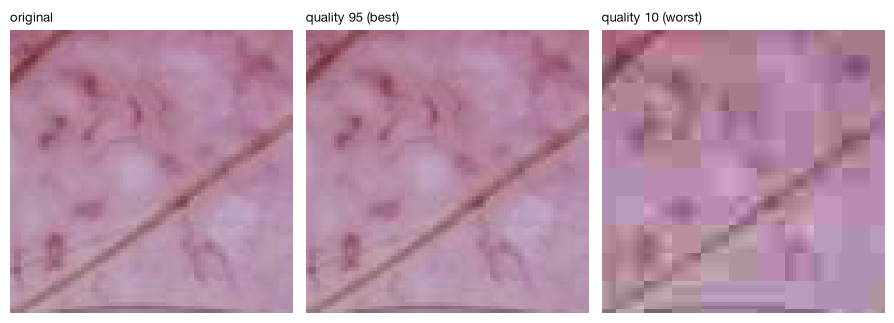

In [8]:
def psnr(a: np.ndarray, b: np.ndarray) -> float:
    """Peak signal-to-noise ratio (dB) between two uint8 images; higher = closer."""
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    return float("inf") if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)

results, decoded = [], {}
for q in (95, 75, 50, 25, 10):
    buf = io.BytesIO()
    Image.fromarray(img).save(buf, format="JPEG", quality=q)       # re-encode in memory
    decoded[q] = np.asarray(Image.open(io.BytesIO(buf.getvalue())).convert("RGB"))
    results.append({"quality": q, "size_KB": buf.tell() / 1024, "PSNR_dB": psnr(img, decoded[q])})
display(pd.DataFrame(results).round(2))

y0, x0, s = h // 2 - 40, w // 2 - 40, 80          # zoom on an 80x80 crop in the centre
fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
for ax, (title, im) in zip(axes, [("original", img), ("quality 95 (best)", decoded[95]), ("quality 10 (worst)", decoded[10])]):
    ax.imshow(im[y0:y0 + s, x0:x0 + s], interpolation="nearest"); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

**Answer A2.2 (a-b).** Lower quality gives smaller files and lower PSNR (29 dB at quality 10, with visible 8&times;8
block artefacts in the zoomed crop). One surprise is that quality 75 gives a *higher* PSNR (65 dB) than quality 95
(51 dB). The original is itself a JPEG, apparently saved at about quality 75, so re-encoding with the same
quantisation tables reproduces almost the same coefficients, while quality 95 uses different tables and adds new
rounding errors. Quality 95 also makes the file larger (73 KB) without bringing back any detail: what the first
compression removed is gone. For a model, this means: (1) the images already carry block artefacts and lost fine
texture, which matters for fine dermoscopic structures; (2) saving them again (double compression) adds artefacts
whose strength depends on the save settings, so preprocessing must never re-encode to JPEG; (3) resizing after
compression smooths the 8&times;8 blocks (600&times;450 &rarr; 224 is a 2&times; downscale), which is fine, but
artefacts that differ between sources or devices can become a shortcut.

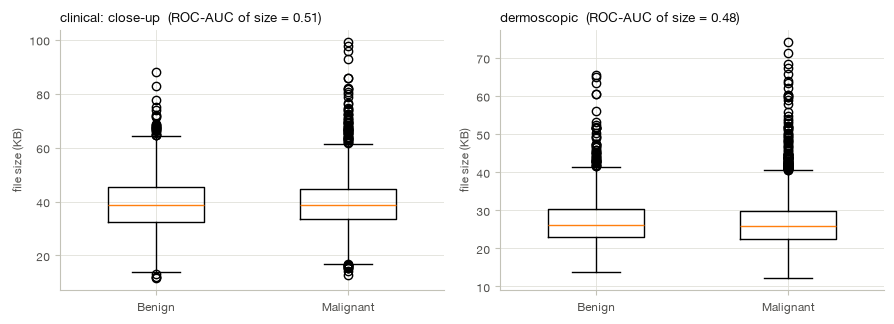

,image_type,median KB Benign,median KB Malignant,ROC-AUC (size -> Malignant)
0,clinical: close-up,38.775,38.802,0.505
1,dermoscopic,26.187,25.815,0.481


In [9]:
from sklearn.metrics import roc_auc_score
sizes = meta.assign(file_kb=[os.stat(image_path(i)).st_size / 1024 for i in meta["isic_id"]])   # no decoding
bm = sizes[sizes["diagnosis_1"].isin(["Benign", "Malignant"])]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.3))
auc_rows = []
for ax, (itype, part) in zip(axes, bm.groupby("image_type")):
    data = [part.loc[part["diagnosis_1"] == c, "file_kb"] for c in ("Benign", "Malignant")]
    ax.boxplot(data, tick_labels=["Benign", "Malignant"], widths=0.5)
    auc = roc_auc_score(part["diagnosis_1"] == "Malignant", part["file_kb"])
    ax.set_title(f"{itype}  (ROC-AUC of size = {auc:.2f})"); ax.set_ylabel("file size (KB)")
    auc_rows.append({"image_type": itype, "median KB Benign": data[0].median(),
                     "median KB Malignant": data[1].median(), "ROC-AUC (size -> Malignant)": auc})
plt.tight_layout(); plt.show()
pd.DataFrame(auc_rows).round(3)

**Answer A2.2 (c).** There is no file-size shortcut: the median sizes of Benign and Malignant images are almost
identical (38.8 vs 38.8 KB for clinical images, 26.2 vs 25.8 KB for dermoscopic ones), and the ROC-AUC of "file size"
as a malignancy score is 0.51 (clinical) and 0.48 (dermoscopic), i.e. chance. All images were re-saved by the
archive at 600&times;450, which removes most device differences. File size could still become a shortcut in other
data through acquisition factors that correlate with the label: different cameras, resolutions or JPEG quality per
clinic (with different case mixes); dermoscope type; rulers, ink or hair adding detail; and lesion size, since large
textured tumours make bigger files. Only the type of image (clinical files are about 50% larger) shows a real
difference here.

# A3. Session 3 &mdash; Splits, imbalance, leakage, augmentation, datasets
## A3.1 Measure the leak

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

FEATURES = ["age_approx", "sex", "anatom_site_general", "image_type"]
CATEGORICAL = ["sex", "anatom_site_general", "image_type"]
data = meta[FEATURES + ["diagnosis_1", "lesion_id"]].copy()
data[CATEGORICAL] = data[CATEGORICAL].astype(object)

def make_model(seed):
    """Imputation and encoding live INSIDE the pipeline, so they are fitted on the training part only."""
    prep = ColumnTransformer([
        ("age", SimpleImputer(strategy="median"), ["age_approx"]),
        ("cat", Pipeline([("fill", SimpleImputer(strategy="constant", fill_value="unknown")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAL)])
    return Pipeline([("prep", prep), ("rf", RandomForestClassifier(n_estimators=200, min_samples_leaf=1,
                                                                   random_state=seed, n_jobs=-1))])

def sibling_oracle(train, test):
    """Predict a test image with the label of its lesion's other image if that one is in train."""
    train_label = train.groupby("lesion_id")["diagnosis_1"].first()
    has_sibling = test["lesion_id"].isin(train_label.index)
    pred = np.where(has_sibling, test["lesion_id"].map(train_label), train["diagnosis_1"].mode()[0])
    return balanced_accuracy_score(test["diagnosis_1"], pred), 100 * has_sibling.mean()

records = []
for seed in range(5):
    naive_tr, naive_te = train_test_split(data, test_size=0.2, stratify=data["diagnosis_1"], random_state=seed)
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    tr_idx, te_idx = next(sgkf.split(data, data["diagnosis_1"], groups=data["lesion_id"]))
    grouped = (data.iloc[tr_idx], data.iloc[te_idx])
    for name, (train, test) in {"(a) naive image-level split": (naive_tr, naive_te),
                                "(b) grouped split (StratifiedGroupKFold)": grouped}.items():
        model = make_model(seed).fit(train[FEATURES], train["diagnosis_1"])
        rf_bacc = balanced_accuracy_score(test["diagnosis_1"], model.predict(test[FEATURES]))
        oracle_bacc, pct_sibling = sibling_oracle(train, test)
        records.append({"split": name, "seed": seed, "RF balanced acc": rf_bacc,
                        "oracle balanced acc": oracle_bacc, "% test images with sibling in train": pct_sibling})
leak = pd.DataFrame(records)
summary = leak.groupby("split")[["RF balanced acc", "oracle balanced acc", "% test images with sibling in train"]].agg(["mean", "std"])
summary.round(3)

RF balanced acc        oracle balanced acc        % test images with sibling in train       
                                                    mean    std                mean    std                                mean    std
split                                                                                                                                
(a) naive image-level split                        0.426  0.004               0.847  0.022                               79.79  1.211
(b) grouped split (StratifiedGroupKFold)           0.426  0.003               0.333  0.000                                0.00  0.000

**Answer A3.1 (d).** The leak did **not** inflate the random forest: its balanced accuracy is 0.426 &plusmn; 0.004 on
the naive image-level split and 0.426 &plusmn; 0.003 on the grouped split. The two images of a lesion share only
age, sex and site, which are coarse (5-year age bins, 4 sites, 2 sexes) and shared by many other lesions, so knowing
that a twin is in train gives the forest almost nothing that it does not already learn from similar lesions. The
sibling oracle shows the leak's *potential*: on the naive split 79.8% of test images have their twin in train, and
copying the twin's label reaches a balanced accuracy of 0.85, against 0.33 (majority class, 0% siblings) on the
grouped split. A model that can recognise a lesion, for example a CNN seeing the dermoscopic and clinical view of the
same lesion or near-duplicate photos, could collect much of that gain and look far better than it is. "I did not
measure any inflation" only means this weak model could not exploit the leak; the grouped split is a property of the
evaluation, required whatever model comes next.

## A3.2 A reusable three-way split

In [11]:
from milk10k.splits import check_no_overlap, split_lesions
print(inspect.getsource(split_lesions))      # lives in milk10k/splits.py

RARE = ["MAL_OTH", "DF", "INF", "VASC", "BEN_OTH"]
dx_of = lesions.set_index("lesion_id")["dx"]
presence = Counter()
for seed in range(10):                       # property test over 10 seeds
    train_ids, val_ids, test_ids = split_lesions(lesions, val_size=0.15, test_size=0.15, seed=seed)
    check_no_overlap({"train": train_ids, "val": val_ids, "test": test_ids})          # no overlap
    for ids, wanted in ((val_ids, 0.15), (test_ids, 0.15), (train_ids, 0.70)):
        assert abs(len(ids) / len(lesions) - wanted) <= 0.01                           # +-1 pp
    assert split_lesions(lesions, 0.15, 0.15, seed=seed) == (train_ids, val_ids, test_ids)  # same seed
    for c in RARE:
        presence[c] += bool((dx_of[val_ids] == c).any() and (dx_of[test_ids] == c).any())
print("property test passed for 10 seeds (no overlap, sizes within 1 pp, reproducible)")
pd.Series(presence, name="seeds (of 10) with the class in val AND test").reindex(RARE).to_frame().assign(
    lesions=lesions["dx"].value_counts().reindex(RARE))

def split_lesions(lesions: pd.DataFrame, val_size: float = config.VAL_SIZE,
                  test_size: float = config.TEST_SIZE, seed: int = config.SEED,
                  label_col: str = config.CLASS_COL, n_folds: int = 20) -> Tuple[List[str], List[str], List[str]]:
    """Return (train, val, test) lists of lesion_id.

    StratifiedGroupKFold cuts the lesions into ``n_folds`` small stratified folds (5% each
    by default); ``test_size`` and ``val_size`` are then made of whole folds (15% = 3
    folds), chosen at random with ``seed``. Same seed -> identical split.
    """
    if not 0 < val_size + test_size < 1:
        raise ValueError("val_size + test_size must be between 0 and 1")
    sgkf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    fold = np.empty(len(lesions), dtype=int)
    with warnings.catch_warnings():   # expected: MAL_OTH has 9 lesions, fewer than the 20 folds
        warnings.filterwarnings("ignore", message="The least populated class"

property test passed for 10 seeds (no overlap, sizes within 1 pp, reproducible)


,seeds (of 10) with the class in val AND test,lesions
MAL_OTH,9,9
DF,10,52
INF,10,50
VASC,10,47
BEN_OTH,10,44


**Answer A3.2.** The property test passes for all 10 seeds: no lesion is shared between any two splits, val and
test are 15% &plusmn; 1 pp and train 70% &plusmn; 1 pp, and the same seed always returns the same split. DF, INF,
VASC and BEN_OTH (44-52 lesions each) are present in both val and test for every seed, about 7 lesions per split.
MAL_OTH (9 lesions) is present in both for 9 of the 10 seeds, but only with 1-3 lesions, and the final project split
(seed 42) has 3 in val and **none** in test. Evaluating the rarest class is therefore not meaningful: a recall
computed on 0-3 lesions is noise, and it can be missing entirely. MAL_OTH must be merged (the OTHER class of the
stretch goal), evaluated with cross-validation over all 9 lesions, or reported with an explicit warning.

## A3.3 Why StratifiedGroupKFold?

In [12]:
from sklearn.model_selection import GroupKFold, StratifiedKFold

def fold_metrics(fold_of_image: pd.Series) -> dict:
    """Leakage and class balance of a 5-fold assignment given per image."""
    leaked = int((images.assign(fold=fold_of_image).groupby("lesion_id")["fold"].nunique() > 1).sum())
    pct = pd.crosstab(images["dx"], fold_of_image, normalize="columns").mul(100)   # class % per validation fold
    counts = pd.crosstab(images["dx"], fold_of_image)
    return {"leaked lesions": leaked,
            "largest spread of a class % across folds (pp)": round(float((pct.max(axis=1) - pct.min(axis=1)).max()), 2),
            "class with that spread": (pct.max(axis=1) - pct.min(axis=1)).idxmax(),
            "folds with no MAL_OTH in validation": int((counts.loc["MAL_OTH"] == 0).sum())}

def lesion_folds_to_images(splitter, **kwargs) -> pd.Series:
    fold = np.empty(len(lesions), dtype=int)
    for k, (_, idx) in enumerate(splitter.split(lesions, **kwargs)):
        fold[idx] = k
    return images["lesion_id"].map(dict(zip(lesions["lesion_id"], fold)))

image_fold = np.empty(len(images), dtype=int)
for k, (_, idx) in enumerate(StratifiedKFold(5, shuffle=True, random_state=0).split(images, images["dx"])):
    image_fold[idx] = k

strategies = {
    "(i) GroupKFold (lesion table)": lesion_folds_to_images(GroupKFold(5), groups=lesions["lesion_id"]),
    "(ii) StratifiedKFold (image table)": pd.Series(image_fold, index=images.index),
    "(iii) StratifiedGroupKFold (lesion table)": lesion_folds_to_images(
        StratifiedGroupKFold(5, shuffle=True, random_state=0), y=lesions["dx"], groups=lesions["lesion_id"]),
}
pd.DataFrame({name: fold_metrics(f) for name, f in strategies.items()}).T

,leaked lesions,largest spread of a class % across folds (pp),class with that spread,folds with no MAL_OTH in validation
(i) GroupKFold (lesion table),0,3.63,NV,0
(ii) StratifiedKFold (image table),4250,0.05,AKIEC,0
(iii) StratifiedGroupKFold (lesion table),0,0.1,AKIEC,0


**Answer A3.3.** StratifiedKFold on the image table leaks **4,250 of 5,240 lesions** (the two images of 81% of the
lesions end up in different folds). GroupKFold leaks nothing, but without stratification a class share varies by up
to 3.6 pp between validation folds (NV). StratifiedGroupKFold leaks nothing **and** keeps every class share within
0.1 pp, with MAL_OTH in every validation fold. I use StratifiedGroupKFold: it is the only strategy that is both
leak-free and class-balanced, which matters for the rare classes.

## A3.4 Metrics and the cost of errors

,pred Benign,pred Indeterminate,pred Malignant
true Benign,0,1,1
true Indeterminate,5,0,5
true Malignant,50,5,0


,accuracy,balanced accuracy,macro-F1,expected cost per lesion
predictor,,,,
always-Malignant,0.696,0.333,0.274,0.391
stratified-random,0.553,0.318,0.319,10.335
uniform-random,0.319,0.366,0.257,13.555
always-Benign,0.282,0.333,0.147,34.905


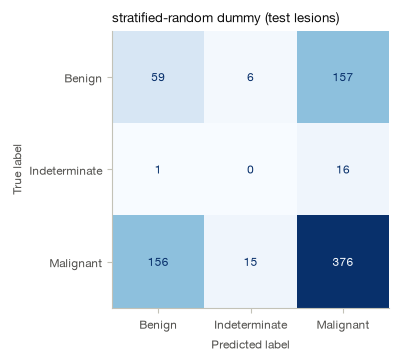

expected cost per lesion of each constant prediction: {'Benign': np.float64(34.905), 'Indeterminate': np.float64(3.762), 'Malignant': np.float64(0.391)}


In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score

split_lesions_tables = {name: pd.read_csv(config.SPLITS_DIR / f"{name}.csv").drop_duplicates("lesion_id")
                        for name in ("train", "test")}            # the project split (Part B), lesion level
y_train = split_lesions_tables["train"]["diagnosis_1"]
y_test = split_lesions_tables["test"]["diagnosis_1"]
LABELS = ["Benign", "Indeterminate", "Malignant"]
COST = pd.DataFrame([[0, 1, 1],      # true Benign: any unnecessary work-up costs 1
                     [5, 0, 5],      # true Indeterminate: errors cost 5
                     [50, 5, 0]],    # true Malignant: missed (called Benign) 50; called Indeterminate 5
                    index=[f"true {c}" for c in LABELS], columns=[f"pred {c}" for c in LABELS])
display(COST)

dummies = {"always-Malignant": DummyClassifier(strategy="constant", constant="Malignant"),
           "stratified-random": DummyClassifier(strategy="stratified", random_state=0),
           "uniform-random": DummyClassifier(strategy="uniform", random_state=0),
           "always-Benign": DummyClassifier(strategy="constant", constant="Benign")}
rows, preds = [], {}
for name, model in dummies.items():
    pred = model.fit(np.zeros((len(y_train), 1)), y_train).predict(np.zeros((len(y_test), 1)))
    preds[name] = pred
    cm = confusion_matrix(y_test, pred, labels=LABELS)
    rows.append({"predictor": name, "accuracy": accuracy_score(y_test, pred),
                 "balanced accuracy": balanced_accuracy_score(y_test, pred),
                 "macro-F1": f1_score(y_test, pred, average="macro", zero_division=0),
                 "expected cost per lesion": (cm * COST.to_numpy()).sum() / len(y_test)})
display(pd.DataFrame(rows).set_index("predictor").round(3))

fig, ax = plt.subplots(figsize=(4.2, 3.6))
ConfusionMatrixDisplay(confusion_matrix(y_test, preds["stratified-random"], labels=LABELS),
                       display_labels=LABELS).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("stratified-random dummy (test lesions)"); ax.grid(False); plt.show()

constant_cost = {c: (confusion_matrix(y_test, [c] * len(y_test), labels=LABELS) * COST.to_numpy()).sum() / len(y_test)
                 for c in LABELS}
print("expected cost per lesion of each constant prediction:", {k: round(v, 3) for k, v in constant_cost.items()})

**Answer A3.4.** On the 786 test lesions, always-Malignant has the best accuracy (0.696) but a balanced accuracy of
only 0.333; stratified-random reaches accuracy 0.553 and uniform-random 0.319. All three are around 0.32-0.37 in
balanced accuracy, i.e. none has learned anything. With the cost matrix shown (missed Malignant 50, any unnecessary
work-up of a Benign 1, Indeterminate errors 5), the expected cost per lesion is 0.39 for always-Malignant, 10.3 for
stratified-random, 13.6 for uniform-random and 34.9 for always-Benign. (c) The optimal constant prediction is
**Malignant** (0.39, vs 3.76 for Indeterminate and 34.9 for Benign): with 69% malignant lesions and a 50:1 cost
ratio, sending everything to work-up is cheapest. Here the ranking by accuracy happens to agree with the ranking by
cost, but for different reasons: accuracy rewards the majority class, while cost rewards never missing a cancer.
Balanced accuracy and macro-F1 rank the dummies differently again. In a real clinic, where most lesions are benign,
accuracy would favour always-Benign, the most expensive choice, so the operating point has to be chosen on cost or
recall, not accuracy.

## A3.5 Is this augmentation label-safe? A quantitative audit

In [14]:
import torchvision.transforms.functional as TF

def otsu_threshold(gray: np.ndarray) -> int:
    """Grey level that best separates dark from bright pixels (Otsu's method)."""
    p = np.bincount(gray.ravel(), minlength=256) / gray.size
    omega, mu = np.cumsum(p), np.cumsum(p * np.arange(256))
    between = (mu[-1] * omega - mu) ** 2 / (omega * (1 - omega) + 1e-12)
    return int(np.argmax(between))

def lesion_mask(rgb: np.ndarray) -> np.ndarray:
    """Lesion = pixels darker than the Otsu threshold inside the central ellipse (skips dark corners)."""
    gray = np.asarray(Image.fromarray(rgb).convert("L"))
    hh, ww = gray.shape
    yy, xx = np.ogrid[:hh, :ww]
    centre = ((yy - hh / 2) / (0.45 * hh)) ** 2 + ((xx - ww / 2) / (0.45 * ww)) ** 2 <= 1
    return centre & (gray <= otsu_threshold(gray[centre]))

def hue_and_value(rgb: np.ndarray, mask: np.ndarray):
    """Circular mean hue (degrees) and mean brightness V (0-1) of the masked pixels."""
    hsv = np.asarray(Image.fromarray(rgb).convert("HSV")).astype(float)
    angles = hsv[..., 0][mask] / 255 * 2 * np.pi
    hue = np.degrees(np.arctan2(np.sin(angles).mean(), np.cos(angles).mean())) % 360
    return hue, hsv[..., 2][mask].mean() / 255

def circ_diff(a, b):
    return (a - b + 180) % 360 - 180          # signed angle difference in degrees

derm = images[images["image_type"] == "dermoscopic"]
samples, rows = {}, []
for group in ("Benign", "Malignant"):
    for iid in derm[derm["diagnosis_1"] == group]["isic_id"].sample(100, random_state=config.SEED):
        im = Image.open(image_path(iid)).convert("RGB"); im.thumbnail((300, 300))
        mask = lesion_mask(np.asarray(im))
        hue, value = hue_and_value(np.asarray(im), mask)
        samples[iid] = (im, mask)
        rows.append({"group": group, "hue": hue, "V": value})
lesion_colour = pd.DataFrame(rows)
mean_hue = lesion_colour.groupby("group")["hue"].apply(
    lambda d: np.degrees(np.arctan2(np.sin(np.radians(d)).mean(), np.cos(np.radians(d)).mean())) % 360)
mean_v = lesion_colour.groupby("group")["V"].mean()
gap_hue = abs(circ_diff(mean_hue["Malignant"], mean_hue["Benign"]))
gap_v = abs(mean_v["Malignant"] - mean_v["Benign"])
print(f"lesion pixels, 100 dermoscopic images per group: mean hue Benign {mean_hue['Benign']:.1f} deg, "
      f"Malignant {mean_hue['Malignant']:.1f} deg -> class gap {gap_hue:.1f} deg")
print(f"mean brightness V: Benign {mean_v['Benign']:.3f}, Malignant {mean_v['Malignant']:.3f} -> class gap {gap_v:.3f}")

audit = []
for hue in (0.02, 0.05, 0.1, 0.5):            # ColorJitter(hue=h) shifts hue by up to h * 360 degrees
    shifts = [abs(circ_diff(hue_and_value(np.asarray(TF.adjust_hue(im, sign * hue)), m)[0],
                            hue_and_value(np.asarray(im), m)[0]))
              for im, m in samples.values() for sign in (-1, 1)]
    audit.append({"augmentation": f"ColorJitter(hue={hue})", "max change (theory)": f"{hue * 360:.0f} deg",
                  "measured mean change at the extremes": f"{np.mean(shifts):.1f} deg",
                  "class gap": f"{gap_hue:.1f} deg", "larger than the class gap?": np.mean(shifts) > gap_hue})
for b in (0.1, 0.3, 0.6):                     # ColorJitter(brightness=b) multiplies by a factor in [1-b, 1+b]
    changes = [abs(hue_and_value(np.asarray(TF.adjust_brightness(im, f)), m)[1] - hue_and_value(np.asarray(im), m)[1])
               for im, m in samples.values() for f in (1 - b, 1 + b)]
    audit.append({"augmentation": f"ColorJitter(brightness={b})", "max change (theory)": f"x{1 - b:.1f} to x{1 + b:.1f}",
                  "measured mean change at the extremes": f"{np.mean(changes):.3f} V",
                  "class gap": f"{gap_v:.3f} V", "larger than the class gap?": np.mean(changes) > gap_v})
pd.DataFrame(audit)

lesion pixels, 100 dermoscopic images per group: mean hue Benign 2.1 deg, Malignant 357.2 deg -> class gap 5.0 deg
mean brightness V: Benign 0.542, Malignant 0.630 -> class gap 0.088


,augmentation,max change (theory),measured mean change at the extremes,class gap,larger than the class gap?
0,ColorJitter(hue=0.02),7 deg,6.9 deg,5.0 deg,True
1,ColorJitter(hue=0.05),18 deg,16.6 deg,5.0 deg,True
2,ColorJitter(hue=0.1),36 deg,34.7 deg,5.0 deg,True
3,ColorJitter(hue=0.5),180 deg,178.6 deg,5.0 deg,True
4,ColorJitter(brightness=0.1),x0.9 to x1.1,0.059 V,0.088 V,False
5,ColorJitter(brightness=0.3),x0.7 to x1.3,0.173 V,0.088 V,True
6,ColorJitter(brightness=0.6),x0.4 to x1.6,0.321 V,0.088 V,True


**Answer A3.5.** (a) On lesion pixels (Otsu threshold inside the central ellipse) of 100 dermoscopic images per
group, Benign and Malignant differ by only **5.0&deg;** in mean hue and **0.088** in mean brightness V. Every hue
setting changes colour *more* than the class gap: hue = 0.02 already shifts the hue by about 7&deg;, and 0.05, 0.1
and 0.5 by 17&deg;, 35&deg; and 179&deg; (0.5 turns skin green or blue). Brightness 0.1 stays below the class gap
(0.059 V), while 0.3 (0.173) and 0.6 (0.321) exceed it.
(b) Safe: horizontal and vertical flips and 90&deg; rotations (skin has no "up"), crops that keep at least 75% of
the image so the lesion stays in view, and mild brightness or contrast (&le;&nbsp;0.1), all comparable to normal
variation in lighting. Risky: any hue jitter, strong saturation or brightness, crops that can cut the lesion out,
and blur or heavy compression that erase fine structures such as pigment network and vessels. This is why
`train_transform` uses `hue=0` and `brightness=0.1`. Approval: every augmentation is a claim that the label does not
change, so a dermatologist must sign off the list, with the data scientist showing examples such as the B7 figure.

## A3.6 A lesion-level Dataset

In [15]:
import torch
import torchvision.transforms as T
from torch.utils.data import DataLoader
from milk10k.dataset import LesionDataset, aggregate_predictions
print(inspect.getsource(LesionDataset))      # lives in milk10k/dataset.py

tf = T.Compose([T.Resize(224), T.CenterCrop(224), T.ToTensor()])
label_map = {"Benign": 0, "Indeterminate": 1, "Malignant": 2}
dataset = LesionDataset(lesions, label_col="diagnosis_1", transform=tf, label_map=label_map)

# (a) one batch of 8: shapes per view, and lesion_ids / labels match the label table
batch = next(iter(DataLoader(dataset, batch_size=8, shuffle=False)))
for view in ("derm", "clinical"):
    assert batch[view].shape == (8, 3, 224, 224), batch[view].shape
expected = lesions.set_index("lesion_id").loc[list(batch["lesion_id"]), "diagnosis_1"].map(label_map).tolist()
assert batch["label"].tolist() == expected
print("(a) shapes:", {v: tuple(batch[v].shape) for v in ("derm", "clinical")}, "| ids:", list(batch["lesion_id"][:3]), "...")

class LesionDataset(Dataset):
    """One item = one lesion: ``{"derm": tensor, "clinical": tensor, "label": int, "lesion_id": str}``.

    ``lesion_table`` needs the columns ``lesion_id``, ``derm_id``, ``clinical_id`` and the label
    column (see ``labels.lesion_table``). The transform is applied to each view separately,
    so each view gets its own random augmentation.
    """

    VIEW_COLUMNS = {"derm": "derm_id", "clinical": "clinical_id"}

    def __init__(self, lesion_table: TableLike, img_dir: Optional[Path] = None,
                 label_col: str = config.TARGET_COL, transform=None,
                 views: Sequence[str] = ("derm", "clinical"), label_map: Optional[Dict[str, int]] = None):
        df = _read_table(lesion_table)
        bad_views = set(views) - set(self.VIEW_COLUMNS)
        if bad_views:
            raise ValueError(f"unknown views {sorted(bad_views)}; choose from {list(self.VIEW_COLUMNS)}")
        missing = [df.at[r, self.VIEW_COLUMNS[v]] for v in views for r

In [16]:
# (b) one epoch over 800 lesions: the class counts seen equal the class counts of the subset
subset = lesions.sample(800, random_state=config.SEED)
seen, start = Counter(), time.perf_counter()
for b in DataLoader(LesionDataset(subset, transform=tf, label_map=label_map), batch_size=8, shuffle=True):
    seen.update(b["label"].tolist())
names = {i: c for c, i in label_map.items()}
seen = {names[k]: v for k, v in seen.items()}
assert seen == subset["diagnosis_1"].value_counts().to_dict()
print(f"(b) epoch over 800 lesions (1,600 images) in {time.perf_counter() - start:.1f} s; counts seen = subset counts:", seen)

(b) epoch over 800 lesions (1,600 images) in 2.6 s; counts seen = subset counts: {'Malignant': 571, 'Benign': 207, 'Indeterminate': 22}


In [17]:
# (c) image-level probabilities -> one prediction per lesion (average of the two views)
print(inspect.getsource(aggregate_predictions))
rng = np.random.default_rng(0)
toy = pd.DataFrame({"isic_id": [f"img_{i}" for i in range(6)], "lesion_id": ["L1", "L1", "L2", "L2", "L3", "L3"]})
probs = rng.dirichlet(np.ones(3), size=6)              # synthetic probabilities, rows sum to 1
per_lesion_pred = aggregate_predictions(probs, toy)
manual = np.stack([probs[0:2].mean(0), probs[2:4].mean(0), probs[4:6].mean(0)])
assert np.allclose(per_lesion_pred[[0, 1, 2]].to_numpy(), manual)
assert (per_lesion_pred["pred"].to_numpy() == manual.argmax(axis=1)).all()
per_lesion_pred.round(3)

def aggregate_predictions(image_probs: np.ndarray, image_table: pd.DataFrame) -> pd.DataFrame:
    """Average the class probabilities of each lesion's images -> one prediction per lesion.

    ``image_probs`` is (n_images, n_classes), row i belonging to row i of ``image_table``
    (which needs a ``lesion_id`` column). Returns one row per lesion: the mean probability
    of every class and ``pred`` (the class with the highest mean probability).
    """
    probs = np.asarray(image_probs, dtype=float)
    if len(probs) != len(image_table):
        raise ValueError("image_probs and image_table must have the same number of rows")
    frame = pd.DataFrame(probs, columns=list(range(probs.shape[1])))
    frame["lesion_id"] = image_table["lesion_id"].to_numpy()
    lesion = frame.groupby("lesion_id").mean()
    lesion["pred"] = lesion.to_numpy().argmax(axis=1)
    return lesion



,0,1,2,pred
lesion_id,,,,
L1,0.198,0.423,0.379,1
L2,0.403,0.265,0.332,0
L3,0.430,0.372,0.197,0


**Answer A3.6 (d).** The unit of evaluation is the **lesion**: the clinical decision (biopsy or not) is made per
lesion, and the two images of a lesion are not independent samples. Evaluating per image counts every lesion twice,
which makes confidence intervals look narrower than they are, and lets the two views disagree without a single
answer for the patient. If images instead of lesions were split, a lesion could even have one view in train and the
other in test, the leak measured in A3.1. Per-image predictions are therefore combined per lesion (`aggregate_predictions`
averages the two views) before computing any metric.